# **Diplomado IA: Audio y Video - Parte 1**. <br> Práctico 3: Redes Convolucionales y Modelos Preentrenados
---
---

**Profesores:**
- Juan Pablo de Vicente
- Gabriel Sepúlveda
- Álvaro Soto
---
---

El siguiente práctico se debe realizar de forma individual. El formato de entregar es el **archivo .ipynb con todas las celdas ejecutadas**. Las secciones donde se planteen preguntas de forma explícita, deben ser respondida en celdas de texto, y no se aceptará solo el _output_ de una celda de código como respuesta.

**Nombre alumno:**Vicente Zapata

El siguiente práctico cuanta con 3 secciones donde cada una contendrá 1 o más actividades a realizar. Algunas actividades corresponderán a escribir código y otras a responder preguntas.

Antes de responder, se recomienda **fuertemente** revisar las secciones previas donde se desarrollan los ejemplos, dado que algunas de las actividades pueden ser completadas reutilizando el mismo código.


---
**IMPORTANTE:** habrá un bonus de 1 décima para todos aquellos alumnos/as que muestren buen orden en sus respuestas (esto aplica a legibilidad de código, buena redacción, formalidad, organización del jupyter notebook, seguimiento de instrucciones, etc). El criterio lo pondrá cada ayudante corrector. La nota máxima obtenible en el laboratorio es 7.0

### Préambulo

Instalamos las herramientas que necesitamos:

In [1]:
!pip3 install resampy
!pip install -U soundfile
!apt-get -y install ffmpeg
!pip uninstall -y torch torchaudio torchcodec
!pip install -U --no-cache-dir torch torchaudio torchcodec  --index-url https://download.pytorch.org/whl/cu126




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 53.9 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Found existing installation: torchcodec 0.10.0+cu128
Uninstalling torchcodec-0.10.0+cu128:
  Successfully uninstalled torchcodec-0.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 95.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 185.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 327.0 M

In [2]:
import torch, torchaudio
print("torch:", torch.__version__)
print("torchaudio:", torchaudio.__version__)

torch: 2.11.0+cu126
torchaudio: 2.11.0+cu126


## Utilitarios

In [3]:
def num_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Parte 1: Conociendo la familia de redes M.

En esta primera parte del laboratorio conoceremos la familia de redes M (M3, M5, M11, M18 y M34_RES) y las utilizaremos para resolver un problema previo que encontramos: el dataset UrbanSound8k. Esta vez, eso sí, en vez de trabajar con los features MFCC, trabajaremos directamente con la señal de audio original. ¿Funcionará bien esto? ¡Veamos!

Paper: https://arxiv.org/pdf/1610.00087.pdf

Código adaptado de: https://github.com/engmubarak48/Very_Deep_CNN_AudioClassification



#### Red M5: Diagrama

* Primera capa hace un *downsampling* **importante**, primero usando un *kernel* de 80, luego con un *stride* de 4 y finalmente con un Max Pooling de *stride* 4. Reduce el tamaño de entrada en un factor de 16 aproximadamente.
* No hay padding.
* Aparte de la primera capa, todas usan *kernels* de tamaño 3.
* Max Pool es siempre de *kernel* 4 y *stride* 4.
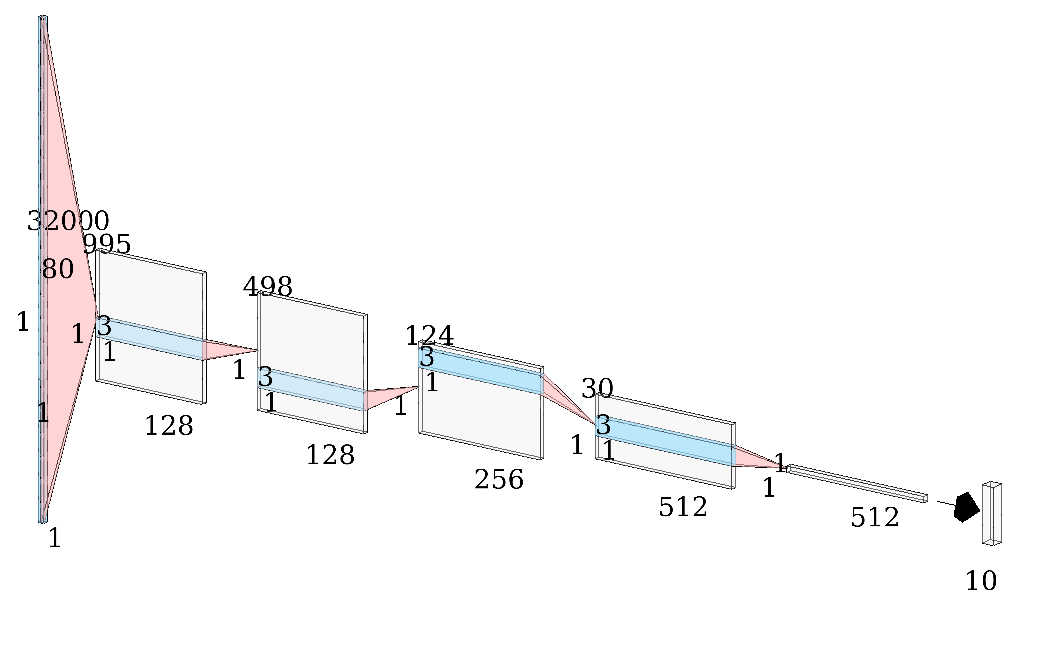

*Diagrama creado con:* http://alexlenail.me/NN-SVG

## Modelos

In [4]:
import torch.nn as nn
import torch
class M3(nn.Module):
    def __init__(self):
        super(M3, self).__init__()
        self.conv1 = nn.Conv1d(1, 256, 80, 4)
        self.bn1 = nn.BatchNorm1d(256)
        self.pool1 = nn.MaxPool1d(4)
        self.conv2 = nn.Conv1d(256, 256, 3)
        self.bn2 = nn.BatchNorm1d(256)
        self.pool2 = nn.MaxPool1d(4)
        self.avgPool = nn.AvgPool1d(498)
        self.fc1 = nn.Linear(256, 10)

    def forward(self, x):
        # Input: (batch_size, 1, 32000)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)      # (batch_size, 256, 1995)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)      # (batch_size, 256, 498)

        x = self.avgPool(x)    # (batch_size, 256, 1)
        x = x.permute(0, 2, 1) # (batch_size, 1, 256)
        x = self.fc1(x)        # (batch_size, 1, 10)
        return x


class M5(nn.Module):
    def __init__(self):
        super(M5, self).__init__()
        self.conv1 = nn.Conv1d(1, 128, 80, 4)   # (1, 32000) --> (128, 7981)
        self.bn1 = nn.BatchNorm1d(128)
        self.pool1 = nn.MaxPool1d(4)            # (128, 7981) --> (128, 1995)
        self.conv2 = nn.Conv1d(128, 128, 3)     # (128, 1995) --> (128, 1993)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(4)            # (128, 1993) --> (128, 498)
        self.conv3 = nn.Conv1d(128, 256, 3)     # (128, 498) --> (256, 496)
        self.bn3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(4)            # (256, 496) --> (256, 124)
        self.conv4 = nn.Conv1d(256, 512, 3)     # (256, 124) --> (512, 122)
        self.bn4 = nn.BatchNorm1d(512)
        self.pool4 = nn.MaxPool1d(4)            # (512, 122) --> (512, 30)
        self.avgPool = nn.AvgPool1d(30)         # (512, 30) --> (512, 1)
        self.fc1 = nn.Linear(512, 10)           # (512 -->  10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(self.bn1(x))
        x = self.pool1(x)
        x = self.conv2(x)
        x = F.relu(self.bn2(x))
        x = self.pool2(x)
        x = self.conv3(x)
        x = F.relu(self.bn3(x))
        x = self.pool3(x)
        x = self.conv4(x)
        x = F.relu(self.bn4(x))
        x = self.pool4(x)
        x = self.avgPool(x)
        x = x.permute(0, 2, 1) #change the 512x1 to 1x512
        x = self.fc1(x)
        return x

# M11
class M11(nn.Module):
    def __init__(self):
        super(M11, self).__init__()
        self.conv1 = nn.Conv1d(1, 64, 80, 4)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(4)

        self.conv2 = nn.Conv1d(64, 64, 3)
        self.conv21 = nn.Conv1d(64, 64, 3)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn21 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(4)

        self.conv3 = nn.Conv1d(64, 128, 3)
        self.conv31 = nn.Conv1d(128, 128, 3)
        self.bn3 = nn.BatchNorm1d(128)
        self.bn31 = nn.BatchNorm1d(128)
        self.pool3 = nn.MaxPool1d(4)

        self.conv4 = nn.Conv1d(128, 256, 3)
        self.conv41 = nn.Conv1d(256, 256, 3)
        self.conv42 = nn.Conv1d(256, 256, 3)
        self.bn4 = nn.BatchNorm1d(256)
        self.bn41 = nn.BatchNorm1d(256)
        self.bn42 = nn.BatchNorm1d(256)
        self.pool4 = nn.MaxPool1d(4)

        self.conv5 = nn.Conv1d(256, 512, 3)
        self.conv51 = nn.Conv1d(512, 512, 3)
        self.bn5 = nn.BatchNorm1d(512)
        self.bn51 = nn.BatchNorm1d(512)

        self.avgPool = nn.AvgPool1d(25)
        self.fc1 = nn.Linear(512, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn21(self.conv21(x)))
        x = self.pool2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn31(self.conv31(x)))
        x = self.pool3(x)

        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn41(self.conv41(x)))
        x = F.relu(self.bn42(self.conv42(x)))
        x = self.pool4(x)

        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn51(self.conv51(x)))
        x = self.avgPool(x)
        x = x.permute(0, 2, 1)
        x = self.fc1(x)
        return x

class M18(nn.Module):
    def __init__(self):
        super(M18, self).__init__()
        self.conv1 = nn.Conv1d(1, 64, 80, 4)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(4)

        self.conv2 = nn.Conv1d(64, 64, 3)
        self.conv21 = nn.Conv1d(64, 64, 3)
        self.conv22 = nn.Conv1d(64, 64, 3)
        self.conv23 = nn.Conv1d(64, 64, 3)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn21 = nn.BatchNorm1d(64)
        self.bn22 = nn.BatchNorm1d(64)
        self.bn23 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(4)

        self.conv3 = nn.Conv1d(64, 128, 3)
        self.conv31 = nn.Conv1d(128, 128, 3)
        self.conv32 = nn.Conv1d(128, 128, 3)
        self.conv33 = nn.Conv1d(128, 128, 3)
        self.bn3 = nn.BatchNorm1d(128)
        self.bn31 = nn.BatchNorm1d(128)
        self.bn32 = nn.BatchNorm1d(128)
        self.bn33 = nn.BatchNorm1d(128)
        self.pool3 = nn.MaxPool1d(4)

        self.conv4 = nn.Conv1d(128, 256, 3)
        self.conv41 = nn.Conv1d(256, 256, 3)
        self.conv42 = nn.Conv1d(256, 256, 3)
        self.conv43 = nn.Conv1d(256, 256, 3)
        self.bn4 = nn.BatchNorm1d(256)
        self.bn41 = nn.BatchNorm1d(256)
        self.bn42 = nn.BatchNorm1d(256)
        self.bn43 = nn.BatchNorm1d(256)
        self.pool4 = nn.MaxPool1d(4)

        self.conv5 = nn.Conv1d(256, 512, 3)
        self.conv51 = nn.Conv1d(512, 512, 3)
        self.conv52 = nn.Conv1d(512, 512, 3)
        self.conv53 = nn.Conv1d(512, 512, 3)
        self.bn5 = nn.BatchNorm1d(512)
        self.bn51 = nn.BatchNorm1d(512)
        self.bn52 = nn.BatchNorm1d(512)
        self.bn53 = nn.BatchNorm1d(512)

        self.avgPool = nn.AvgPool1d(20)
        self.fc1 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(self.bn1(x))
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn21(self.conv21(x)))
        x = F.relu(self.bn22(self.conv22(x)))
        x = F.relu(self.bn23(self.conv23(x)))
        x = self.pool2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn31(self.conv31(x)))
        x = F.relu(self.bn32(self.conv32(x)))
        x = F.relu(self.bn33(self.conv33(x)))
        x = self.pool3(x)


        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn41(self.conv41(x)))
        x = F.relu(self.bn42(self.conv42(x)))
        x = F.relu(self.bn43(self.conv43(x)))
        x = self.pool4(x)

        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn51(self.conv51(x)))
        x = F.relu(self.bn52(self.conv52(x)))
        x = F.relu(self.bn53(self.conv53(x)))
        x = self.avgPool(x)
        x = x.permute(0, 2, 1)
        x = self.fc1(x)
        return x

Alguos comentarios sobre las decisiones de diseño de este modelo:

* En general se ocupan *kernels* pequeños de tamaño 3 en las convoluciones, *excepto* en la primera capa. En ésta se toma un *kernel* de 80. Esto es para reflejar alrededor de 10ms de audio, que es un largo de tiempo estándar usado en otras aplicaciones que ocupan MFCC. Los autores mencionan que lo aprendido por esta primera capa es similar a un filtro pasabandas, es decir, la primera capa aprende a dejar pasar ciertas frecuencias y omitir otras.

* Respecto al resto, vemos un patrón usual con modelos convolucionales de imágenes: una reducción progresiva de la resolución espacial, junto con un aumento progresivo de la cantidad de canales.
* ¿Por qué AvgPool al final? Según autores del paper, esto es para reemplazar las capas Fully Connected usuales y forzar a la parte convolucional a generar buenas representaciones. Observan que un modelo Fully Convolutional anda igual o mejor que usando capas FC.

## Manejando los datos

Esta vez trabajaremos con el formato oficial del Dataset UrbanSound8K. Esto quiere decir, que en vez de tener un split de train, validación y test, ocuparemos los 10 *folds* originales que vienen en el dataset.

### Un ligero desvío: K-Fold Cross Validation

Si recuerdan de su primer laboratorio, entrenamos un MLP sencillo con este mismo dataset que tuvo resultados de más de 90% en el set de test.

Sin embargo, este resultado es poco fiable por una regla básica que fue violada al entrenar ese modelo en ese momento: *el set de entrenamiento no debe estar correlacionado al set de test*. En ese momento, esto no era importante pues nuestro objetivo era entender el audio más que entrenar modelos. Esto lo arreglaremos esta vez. UrbanSound8K cuenta con varios subdatasets que llamaremos *folds*. Con estos *folds* podremos ejecutar una técnica que se llama *K-Fold Cross Validation*, que en palabras simples nos dice:

* Vamos a entrenar K versiones de nuestro modelo.
* Cada una de estas versiones será entrenada con K-1 folds y testeada en el fold restante.
* En el caso de este dataset K=10.

**¿Por qué esta forma tan extraña de probar?**

Porque nos da una idea mejor de cómo generaliza nuestro modelo. Si no hiciésemos esto, podríamos tener la mala suerte de que elegimos un test de prueba fácil o correlacionado y sobreestimamos la capacidad de nuestro algoritmo.

Esta vez, entrenaremos con un fold específico de prueba que sabemos no está correlacionado con el set de entrenamiento. De esta manera deberíamos tener una idea más real del rendimiento de nuestro modelo.

**¿Debería ocupar K-Fold Cross Validation siempre? ¡Suena costoso!**

En general, K-Fold Cross Validation se ocupa sólo cuando tenemos pocos datos. Si tenemos muchos datos (que suele pasar en Deep Learning), es más probable que nuestro set de test sea representativo de la distribución de los datos.

**Tengo K versiones de mi modelo, ¿con cuál me quedo?**

Con ninguna. Usamos Cross Validation para entender el potencial rendimiento de nuestros modelos, pero en la práctica al final ocuparemos todos nuestros datos para entrenar la versión final modelo que queramos usar.

### Descargando el dataset (10 minutos aprox)

Sugiero descargar el dataset y guardarlo en su carpeta de Drive, para no tener que descargarlo cada vez.



In [5]:
!!if [ ! -f UrbanSound8k.tar.gz ]; then wget https://www.dropbox.com/s/p3yxyolm8xxoeiq/UrbanSound8K.tar.gz -O UrbanSound8k.tar.gz -q --show-progress; fi # Descarga del dataset
!tar -xzf UrbanSound8k.tar.gz           # Descomprimimos el dataset

In [6]:
#!tar -xzf  /content/drive/MyDrive/Diplomados/Audio/UrbanSound8k.tar.gz #Esto solo se corre si ya tienen guardado en alguna ruta el dataset

### Clase Dataset

En este caso, nuestra clase dataset tomará como parámetros no sólo las rutas donde están nuestros datos, sino también qué folds queremos que sean incluidos en nuestro dataset. Esto es útil para generar los datasets de entrenamiento y test correctos. Aparte de esto, nuestra clase leerá archivos de audio con $\texttt{torchaudio.load}$ y los dejará de un tamaño fijo

## Código de Entrenamiento

In [8]:
def train(model, epoch, log_interval=10):
    model.train()
    correct = 0
    losses_train = []
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        data = data.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        data = data.requires_grad_() #set requires_grad to True for training
        output = model(data)
        output = output.permute(1, 0, 2) #original output dimensions are batchSizex1x10
        loss = criterion(output[0], target) #the loss functions expects a batchSizex10 input
        losses_train.append(loss.item())
        pred = output.max(2)[1]
        correct += pred.eq(target).cpu().sum().item()
        loss.backward()
        optimizer.step()
        if batch_idx % log_interval == 0: #print training stats
            print('\rEpoca Entrenamiento: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(epoch, batch_idx * len(data), len(train_loader.dataset),
                  100. * batch_idx / len(train_loader), loss), end="")
    print("")
    return 100. * correct / len(train_loader.dataset), np.mean(losses_train)

def test(model, epoch):
    model.eval()
    correct = 0
    test_losses = []
    test_p = []
    test_gts = []
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)
            output = model(data)
            output = output.permute(1, 0, 2)
            # Calculo métricas
            # Pérdida
            loss = criterion(output[0], target) #the loss functions expects a batchSizex10 input
            test_losses.append(loss.item())
            # Exactitud
            pred = output.max(2)[1]                         # Nos quedamos con el mayor valor del output
            test_p.append(pred)
            test_gts.append(target)
            correct += pred.eq(target).cpu().sum().item()   # Sumamos los ejemplos en que le apuntamos a la clase
        test_p = torch.cat([x.squeeze() for x in test_p], dim=0).long()
        test_gts = torch.cat(test_gts, dim=0).long()
    return 100. * correct / len(test_loader.dataset), np.mean(test_losses), test_p, test_gts

### Gráfico de Métricas

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_results(ax, m_train, m_test, label_metrica="Perdida"):
    n_epocas = len(m_train)
    ax.plot(np.arange(n_epocas), m_train, label = 'Train')
    ax.plot(np.arange(n_epocas), m_test, label = 'Test')
    ax.set_title('{} durante Entrenamiento'.format(label_metrica))
    ax.set_xlabel('Épocas')
    ax.set_ylabel(label_metrica)
    ax.legend()
    return ax


# Función tomada de: https://github.com/DTrimarchi10/confusion_matrix
def make_confusion_matrix(cf,
                          group_names=None,
                          categories='auto',
                          count=True,
                          percent=True,
                          cbar=True,
                          xyticks=True,
                          xyplotlabels=True,
                          sum_stats=True,
                          figsize=None,
                          cmap='Blues',
                          title=None):
    '''
    This function will make a pretty plot of an sklearn Confusion Matrix cm using a Seaborn heatmap visualization.
    Arguments
    ---------
    cf:            confusion matrix to be passed in
    group_names:   List of strings that represent the labels row by row to be shown in each square.
    categories:    List of strings containing the categories to be displayed on the x,y axis. Default is 'auto'
    count:         If True, show the raw number in the confusion matrix. Default is True.
    normalize:     If True, show the proportions for each category. Default is True.
    cbar:          If True, show the color bar. The cbar values are based off the values in the confusion matrix.
                   Default is True.
    xyticks:       If True, show x and y ticks. Default is True.
    xyplotlabels:  If True, show 'True Label' and 'Predicted Label' on the figure. Default is True.
    sum_stats:     If True, display summary statistics below the figure. Default is True.
    figsize:       Tuple representing the figure size. Default will be the matplotlib rcParams value.
    cmap:          Colormap of the values displayed from matplotlib.pyplot.cm. Default is 'Blues'
                   See http://matplotlib.org/examples/color/colormaps_reference.html

    title:         Title for the heatmap. Default is None.
    '''


    # CODE TO GENERATE TEXT INSIDE EACH SQUARE
    blanks = ['' for i in range(cf.size)]

    if group_names and len(group_names)==cf.size:
        group_labels = ["{}\n".format(value) for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = ["{0:0.0f}\n".format(value) for value in cf.flatten()]
    else:
        group_counts = blanks

    if percent:
        group_percentages = ["{0:.2%}".format(value) for value in cf.flatten()/np.sum(cf)]
    else:
        group_percentages = blanks

    box_labels = [f"{v1}{v2}{v3}".strip() for v1, v2, v3 in zip(group_labels,group_counts,group_percentages)]
    box_labels = np.asarray(box_labels).reshape(cf.shape[0],cf.shape[1])


    # CODE TO GENERATE SUMMARY STATISTICS & TEXT FOR SUMMARY STATS
    if sum_stats:
        #Accuracy is sum of diagonal divided by total observations
        accuracy  = np.trace(cf) / float(np.sum(cf))

        #if it is a binary confusion matrix, show some more stats
        if len(cf)==2:
            #Metrics for Binary Confusion Matrices
            precision = cf[1,1] / sum(cf[:,1])
            recall    = cf[1,1] / sum(cf[1,:])
            f1_score  = 2*precision*recall / (precision + recall)
            stats_text = "\n\nAccuracy={:0.3f}\nPrecision={:0.3f}\nRecall={:0.3f}\nF1 Score={:0.3f}".format(
                accuracy,precision,recall,f1_score)
        else:
            stats_text = "\n\nAccuracy={:0.3f}".format(accuracy)
    else:
        stats_text = ""


    # SET FIGURE PARAMETERS ACCORDING TO OTHER ARGUMENTS
    if figsize==None:
        #Get default figure size if not set
        figsize = plt.rcParams.get('figure.figsize')

    if xyticks==False:
        #Do not show categories if xyticks is False
        categories=False


    # MAKE THE HEATMAP VISUALIZATION
    plt.figure(figsize=figsize)
    sns.heatmap(cf,annot=box_labels,fmt="",cmap=cmap,cbar=cbar,xticklabels=categories,yticklabels=categories)

    if xyplotlabels:
        plt.ylabel('Verdadero')
        plt.xlabel('Predicho' + stats_text)
    else:
        plt.xlabel(stats_text)

    if title:
        plt.title(title)

### Reproducibilidad:

Dada la naturaleza aleatoria del entrenamiento, tenderá a suceder que entrenar el mismo modelo, con los mismos datos, entregue resultados distintos. Esto tiene que ver con varios puntos:

* Aleatoriedad del orden en que entregamos los datos de entrada al modelo.
* Aleatoriedad de los pesos iniciales del modelo.
* Aleatoriedad intrínseca de operaciones de PyTorch.
* Aleatoriedad inducida por temas extra (Data Augmentation y Random Crops por ejemplo).

Por esto, a la hora de evaluar un modelo, si es posible, trataremos de mitigar esta aleatoriedad para tomar una decisión más informada. Hay dos cosas que podemos hacer:

* Entrenar varios modelos, promediar los resultados y obtener intervalos de confianza (Costoso, pero muy buena práctica).
* Desactivar las fuentes de aleatoriedad en nuestro código (Fácil).

El próximo bloque de código apaga las fuentes de aleatoriedad, fijando que el estado "aleatorio" antes de una corrida del código sea siempre igual, por lo que los eventos aleatorios que sucedan de ahí en adelante serán determinísticos.

In [10]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':16:8'
torch.manual_seed(0)                        # Seteamos las semilla aleatoria de PyTorch
np.random.seed(0)                           # Lo mismo para Numpy
state_np = np.random.get_state()            # Obtenemos el estado aleatorio de Numpy para poder replicarlo después
state_torch = torch.random.get_rng_state()  # Obtenemos el estado aleatorio de PyTorch para poder replicarlo después

# Conditionally set CUDA-specific randomness if a CUDA device is available
if torch.cuda.is_available():
    torch.cuda.manual_seed(0)
    state_torch_cuda = torch.cuda.random.get_rng_state()
    torch.backends.cudnn.benchmark = False      # Otra fuente de aleatoriedad de PyTorch se apaga
else:
    state_torch_cuda = None # Initialize to None if CUDA is not available

torch.use_deterministic_algorithms(True)               # Hacemos que ciertas operaciones que PyTorch hace aleatorias sean determinísticas

### Loop de Entrenamiento

Numero de parametros: 221194


/usr/local/lib/python3.12/dist-packages/torchaudio/__init__.py:86: UserWarning: The 'backend' parameter is not used by TorchCodec AudioDecoder.
  return load_with_torchcodec(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/linear.py:134: UserWarning: Requested unified CUBLASLT workspace size of 1048576 bytes exceeds CUBLAS workspace size of 131072 bytes. Please increase CUBLAS workspace size via CUBLAS_WORKSPACE_CONFIG or decrease requested CUBLASLT_WORKSPACE_SIZE. Otherwise CUBLASLT workspace size will be limited to the CUBLAS workspace size. (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:228.)
  return F.linear(input, self.weight, self.bias)


Epoca Entrenamiento: 0 [8640/8732 (99%)]	Loss: 1.639010
Epoca 1 Completa - Exactitud Train: 31.71% - Exactitud Test: 38.26%
Epoca Entrenamiento: 1 [8640/8732 (99%)]	Loss: 1.718871
Epoca 2 Completa - Exactitud Train: 40.86% - Exactitud Test: 38.49%
Epoca Entrenamiento: 2 [8640/8732 (99%)]	Loss: 1.690026
Epoca 3 Completa - Exactitud Train: 44.25% - Exactitud Test: 45.93%
Epoca Entrenamiento: 3 [8640/8732 (99%)]	Loss: 1.393703
Epoca 4 Completa - Exactitud Train: 45.02% - Exactitud Test: 39.29%
Epoca Entrenamiento: 4 [8640/8732 (99%)]	Loss: 1.655187
Epoca 5 Completa - Exactitud Train: 45.71% - Exactitud Test: 48.00%
Epoca Entrenamiento: 5 [8640/8732 (99%)]	Loss: 1.388991
Epoca 6 Completa - Exactitud Train: 47.95% - Exactitud Test: 44.67%
Epoca Entrenamiento: 6 [8640/8732 (99%)]	Loss: 1.612441
Epoca 7 Completa - Exactitud Train: 48.02% - Exactitud Test: 42.04%
Epoca Entrenamiento: 7 [8640/8732 (99%)]	Loss: 1.339761
Epoca 8 Completa - Exactitud Train: 48.68% - Exactitud Test: 46.62%
Epoca En

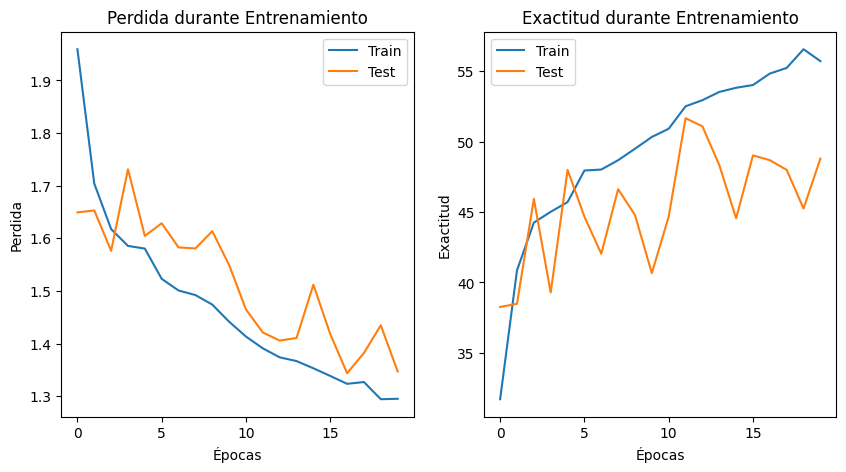

In [11]:
import matplotlib.pyplot as plt
# Reproducibilidad: dejamos el estado de las semillas de aleatoriedad fijo
# en cada ejecución
torch.random.set_rng_state(state_torch)
torch.cuda.random.set_rng_state(state_torch_cuda)
np.random.set_state(state_np)
# Parametros para crear nuestros datasets a partir de los folds establecidos
csv_path = './UrbanSound8K/metadata/UrbanSound8K.csv'
file_path = './UrbanSound8K/audio/'
train_folds = [2,3,4,5,6,7,8,9,10]          # Entrenamos con folds 2-10
test_folds = [1]                            # Testeamos con el fold n°1
train_set = AudioDataset(csv_path, file_path, train_folds)
test_set = AudioDataset(csv_path, file_path, test_folds)
# Estos son parámetros para optimizar un poco la velocidad, no son críticos.
kwargs = {'num_workers': 0} if device == 'cuda' else {}
train_loader = torch.utils.data.DataLoader(train_set, batch_size = 32, shuffle = True, **kwargs)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = 32, shuffle = True, **kwargs)

# Creamos el modelo
net = M3()
#net = M18()           # Descomentar esta línea para entrenar con el modelo M18
net = net.to(device)
net.apply(init_weights) # Inicializamos los pesos de nuestra red con método Xavier

print( 'Numero de parametros: %d' % (num_trainable_parameters(net)) )

#Para guardar el modelo
file_name = 'audio_M3.model' #Con que nombre queremos guardar nuestro modelo
MODELS_ROOT = '.' #En que carpeta queremos guardar el modelo
save_path = os.path.join(MODELS_ROOT, file_name)

# Pérdida usual de Clasificación
criterion = nn.CrossEntropyLoss()
# Optimizador: Adam, no innovaremos.
optimizer = optim.Adam(net.parameters(), lr = 0.01, weight_decay = 0.0001)
# Opcional: el scheduler se encarga de cambiar el learning rate cada N épocas.
# Como está seteado ahora, el cambio sucede cada 20 épocas y multiplica
# la tasa de aprendizaje por 0.1, es decir, la divide por 10.
# En la época 41 la reduciría de nuevo.
# Para las actividades que vamos a ocupar no importa, pero si desean entrenar
# por más épocas puede serles útil.
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size = 20, gamma = 0.1)

# Métricas
# Guardamos la pérdida y la exactitud
loss_epoch_train = []
loss_epoch_test = []
accuracy_epoch_train = []
accuracy_epoch_test = []

# Loop de entrenamiento
n_epochs = 20
best_accuracy = 0.0
best_model = net

for epoch in range(n_epochs):
    accuracy_train, losses_train = train(net, epoch) # 1 época de entrenamiento
    scheduler.step() # Relacionado al Scheduler opcional, si se ocupa, se debe
                     # Hacer step después del fin de cada época
    loss_epoch_train.append(losses_train)         # Actualizamos métricas
    accuracy_epoch_train.append(accuracy_train)
    accuracy_test, losses_test, test_preds, test_gts = test(net, epoch) # Probamos en test cómo vamos
    loss_epoch_test.append(losses_test)           # Actualizamos métricas
    if accuracy_test > best_accuracy:             # Guardamos resultados del mejor modelo
        best_model = net
        best_accuracy = accuracy_test
        best_preds = test_preds
        best_gt = test_gts
        with open(save_path, 'wb') as f:
          state = {
              "optimizer": optimizer.state_dict(), #Guardamos el estado del optimizador
              "model": net.state_dict(), #Los pesos actuales del modelo
              "scheduler": scheduler.state_dict(), #El estado del scheduler del learning rate
              "epoch": epoch, #La epoca en la que estabamos
              "accuracy": accuracy_test, #La precision que tuvo este modelo en validacion
          }
          torch.save(state, f) #Hacemos efectivo el guardado de todas las cosas anteriores
    accuracy_epoch_test.append(accuracy_test)
    print('Epoca {} Completa - Exactitud Train: {:.2f}% - Exactitud Test: {:.2f}%'.format(epoch+1,accuracy_train, accuracy_test))

# Graficar resultados
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0] = plot_results(ax[0],loss_epoch_train, loss_epoch_test, label_metrica="Perdida")
ax[1] = plot_results(ax[1],accuracy_epoch_train, accuracy_epoch_test, label_metrica="Exactitud")
fig.savefig('figure_fold:{0}_model:{1}.png'.format(1, "M3"))

### ¡Probemos el modelo!

In [12]:
clases = ['air_conditioner','car_horn','children_playing','dog_bark','drilling','engine_idling','gun_shot','jack_hammer','siren','street_music']

In [13]:
tensores, labels = next(iter(test_loader)) # Sacamos un batch de test
output = net(tensores.to(device))
output = output.permute(1, 0, 2)
preds = output.max(2)[1]
correct = preds.eq(labels.to(device))
preds = preds.squeeze()
correct = correct.squeeze()
elegidos = torch.nonzero(correct).squeeze().cpu().detach()     # Indices de ejemplos correctos
no_elegidos = torch.nonzero(~correct).squeeze().cpu().detach() # Indices de ejemplos incorrectos
audios_correctos = tensores[elegidos]
labels_correctos = labels[elegidos]
audios_incorrectos = tensores[no_elegidos]
labels_incorrectos = labels[no_elegidos]
iterador_correctos = zip(audios_correctos, labels_correctos)
iterador_incorrectos = zip(audios_incorrectos, preds[no_elegidos], labels_incorrectos)

#### ¡Viendo los ejemplos correctos!

In [14]:
import IPython.display as ipd
audio, label = next(iterador_correctos)
print("Modelo predijo '{}' correctamente!".format(clases[label]))
ipd.Audio(audio, rate=16000)

Modelo predijo 'children_playing' correctamente!


#### ¡Viendo los ejemplos incorrectos!

In [15]:
audio, incorrecto, label = next(iterador_incorrectos)
print("Modelo predijo '{}' pero en verdad era '{}'!".format(clases[incorrecto], clases[label]))
ipd.Audio(audio, rate=16000)

Modelo predijo 'engine_idling' pero en verdad era 'street_music'!


/usr/local/lib/python3.12/dist-packages/torchaudio/__init__.py:86: UserWarning: The 'backend' parameter is not used by TorchCodec AudioDecoder.
  return load_with_torchcodec(


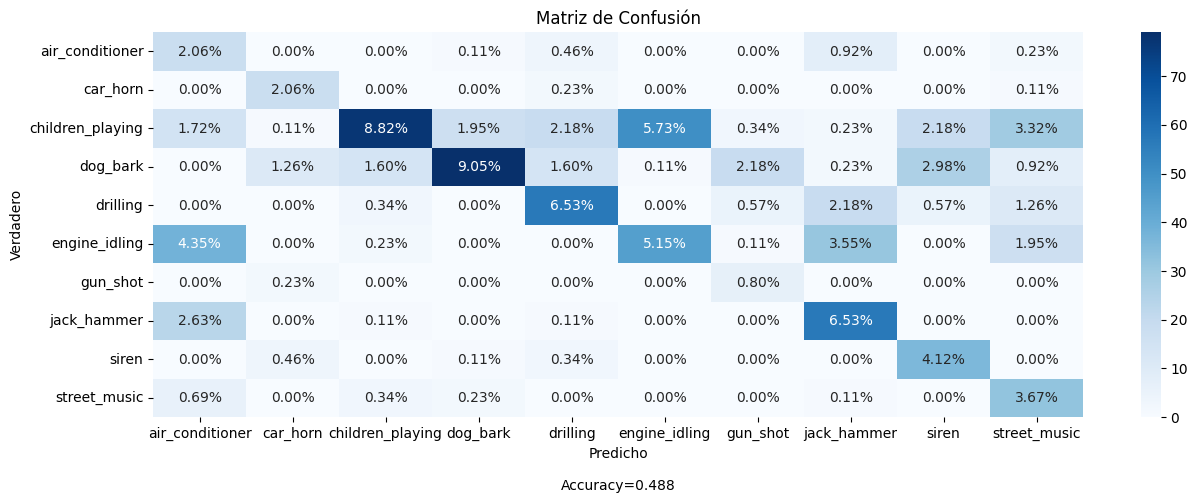

In [16]:
from sklearn.metrics import confusion_matrix, classification_report
accuracy_test, losses_test, test_preds, test_gts = test(net, epoch) # Corremos por una epoca el modelo preentrenado
clases = ['air_conditioner','car_horn','children_playing','dog_bark','drilling','engine_idling','gun_shot','jack_hammer','siren','street_music']
cf = confusion_matrix(test_preds.cpu(), test_gts.cpu())
make_confusion_matrix(cf, categories=clases, count=False,figsize=(15,5),title="Matriz de Confusión")

### Reporte Precision-Recall y F1

In [17]:
result = classification_report(test_gts.cpu(), test_preds.cpu(), labels=None, target_names=clases, digits=2, zero_division='warn')
print(result)

                  precision    recall  f1-score   support

 air_conditioner       0.55      0.18      0.27       100
        car_horn       0.86      0.50      0.63        36
children_playing       0.33      0.77      0.46       100
        dog_bark       0.45      0.79      0.58       100
        drilling       0.57      0.57      0.57       100
   engine_idling       0.34      0.47      0.39        96
        gun_shot       0.78      0.20      0.32        35
     jack_hammer       0.70      0.47      0.56       120
           siren       0.82      0.42      0.55        86
    street_music       0.73      0.32      0.44       100

        accuracy                           0.49       873
       macro avg       0.61      0.47      0.48       873
    weighted avg       0.58      0.49      0.48       873



### Modelo Preentrenado por 50 épocas

Dado que esto puede tomar unas cuantas horas, veamos el resultado de uno de estos modelo entrenado por 50 épocas (con el mismo código) de arriba. Descarguémoslo:

In [18]:
!wget https://www.dropbox.com/s/ws38tacpjd38ocz/m3_50epochs.pth -q --show-progress # Bajamos los modelos preentrenados
!wget https://www.dropbox.com/s/m57bq7dop2m5cjk/m18_50epochs.pth -q --show-progress

m3_50epochs.pth     100%[===================>] 873.25K   952KB/s    in 0.9s    
m18_50epochs.pth    100%[===================>]  14.12M  9.53MB/s    in 1.5s    


#### Cargamos los pesos

In [19]:
pesos = torch.load("m3_50epochs.pth")
net = M3().to(device)
net.load_state_dict(pesos)
accuracy_test, losses_test, test_preds, test_gts = test(net, epoch) # Corremos por una epoca el modelo preentrenado

/usr/local/lib/python3.12/dist-packages/torchaudio/__init__.py:86: UserWarning: The 'backend' parameter is not used by TorchCodec AudioDecoder.
  return load_with_torchcodec(


#### ¡Viendo los ejemplos correctos!

In [20]:
import IPython.display as ipd
audio, label = next(iterador_correctos)
print("Modelo predijo '{}' correctamente!".format(clases[label]))
ipd.Audio(audio, rate=16000)

Modelo predijo 'dog_bark' correctamente!


#### ¡Viendo los ejemplos incorrectos!

In [21]:
audio, incorrecto, label = next(iterador_incorrectos)
print("Modelo predijo '{}' pero en verdad era '{}'!".format(clases[incorrecto], clases[label]))
ipd.Audio(audio, rate=16000)

Modelo predijo 'children_playing' pero en verdad era 'engine_idling'!


### Matriz de Confusión

Ahora veamos un poco el rendimiento más desagregado por clase. En particular miraremos la Matriz de Confusión y el *Precision* y *Recall* para cada clase. Éstas nos darán una visión más particular del rendimiento de nuestro modelo en cada clase, permitiéndonos entender sus fortalezas y debilidades.

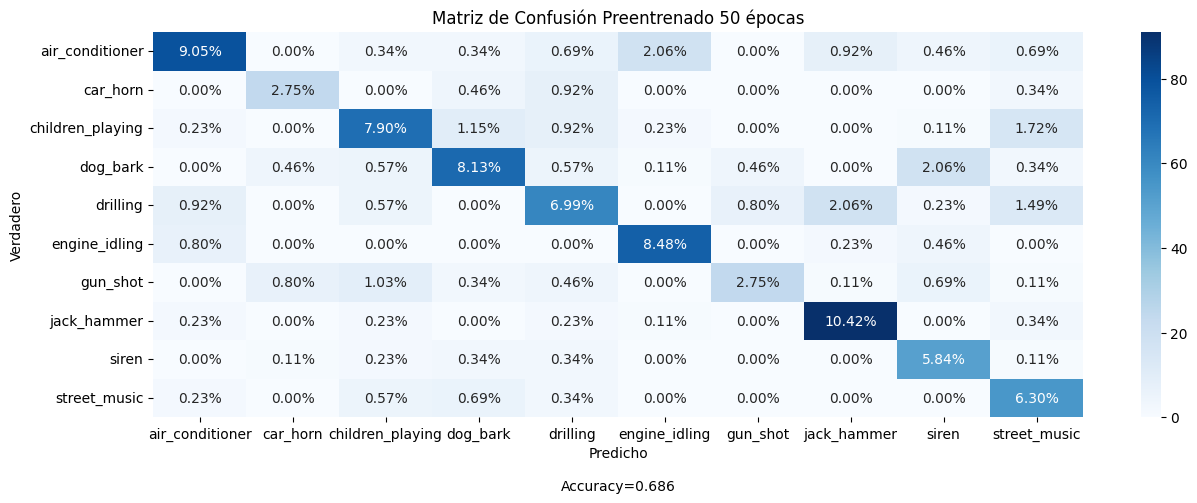

In [22]:
from sklearn.metrics import confusion_matrix, classification_report
clases = ['air_conditioner','car_horn','children_playing','dog_bark','drilling','engine_idling','gun_shot','jack_hammer','siren','street_music']
cf = confusion_matrix(test_preds.cpu(), test_gts.cpu())
make_confusion_matrix(cf, categories=clases, count=False,figsize=(15,5),title="Matriz de Confusión Preentrenado 50 épocas")

### Reporte Precision-Recall y F1

In [23]:
result = classification_report(test_gts.cpu(), test_preds.cpu(), labels=None, target_names=clases, digits=2, zero_division='warn')
print(result)

                  precision    recall  f1-score   support

 air_conditioner       0.62      0.79      0.70       100
        car_horn       0.62      0.67      0.64        36
children_playing       0.64      0.69      0.67       100
        dog_bark       0.64      0.71      0.67       100
        drilling       0.54      0.61      0.57       100
   engine_idling       0.85      0.77      0.81        96
        gun_shot       0.44      0.69      0.53        35
     jack_hammer       0.90      0.76      0.82       120
           siren       0.84      0.59      0.69        86
    street_music       0.77      0.55      0.64       100

        accuracy                           0.69       873
       macro avg       0.69      0.68      0.67       873
    weighted avg       0.71      0.69      0.69       873



---
## Explicación Actividad 1 — ¿Qué cambiaría si usamos MFCC?

Antes de responder, recordemos cómo funciona el pipeline **actual**:

1. **`AudioDataset`** carga el audio **en crudo** (raw waveform), lo convierte a mono y lo rellena hasta **32 000 muestras** → un vector 1D de forma `(32000,)`
2. Los modelos **M-family (M3, M5, M11…)** usan **Convoluciones 1D** (`nn.Conv1d`) porque esperan ese vector unidimensional como entrada.

¿Qué pasaría si pasamos a usar **MFCC**?

| Aspecto | Audio crudo (actual) | MFCC |
|---|---|---|
| Forma de entrada | `(32000,)` — vector 1D | `(n_mfcc, T)` — matriz 2D |
| Tipo de convolución | `Conv1d` | `Conv2d` (como hace VGGish) |
| Transformación en el Dataset | Ninguna extra | Hay que calcular los MFCC |

### ¿Cuáles opciones son **necesariamente** ciertas?

* **B — Agregar una transformación MFCC a los datos** → ✅ **VERDADERO**
  El `AudioDataset` actual no aplica ninguna transformación; habría que usar `torchaudio.transforms.MFCC` para convertir el audio crudo a coeficientes MFCC antes de pasárselo al modelo.

* **D — Modificar la arquitectura del modelo** → ✅ **VERDADERO**
  Los modelos M-family usan `Conv1d` y esperan un tensor 1D. Un MFCC es 2D (tiempo × frecuencia), así que habría que rediseñar la arquitectura con `Conv2d`, exactamente como ocurre con VGGish en la Parte 2.

* **A** (cambiar la frecuencia de muestreo), **C** (aumentar la cantidad de datos), **E** (ajustar el LR) y **F** (cambiar la loss) **NO son cambios necesariamente obligatorios** solo por cambiar a MFCC.

> **Respuesta: B = True, D = True**

### Actividad 1:

¿Qué cambios tendríamos que hacer necesariamente para entrenar con features MFCC en vez del audio puro como lo estamos haciendo acá? Puede haber más de una respuesta correcta.

* A - Resamplear el audio a otra Frecuencia de Muestreo
* B - Agregar una transformación MFCC a los datos
* C - Aumentar la cantidad de datos de entrada
* D - Modificar la arquitectura del modelo
* E - Ajustar la tasa de aprendizaje
* F - Cambiar la función de pérdida

In [24]:
#@title Actividad 1
A = False  #@param {type:"boolean"}   # No es necesario cambiar la frecuencia de muestreo solo por usar MFCC
B = True   #@param {type:"boolean"}   # ✅ Hay que agregar la transformación MFCC en el Dataset
C = False  #@param {type:"boolean"}   # No aumenta la cantidad de datos de entrada
D = True   #@param {type:"boolean"}   # ✅ Hay que cambiar la arquitectura a Conv2d (los modelos M usan Conv1d)
E = False  #@param {type:"boolean"}   # El learning rate no necesita cambiar por usar MFCC
F = False  #@param {type:"boolean"}   # La función de pérdida CrossEntropyLoss sigue siendo válida

---
## Explicación Actividad 2 — Entrenando el modelo M5

### ¿Qué es M5?

El modelo **M5** es una versión más profunda que M3. Tiene **5 bloques de convolución 1D**, lo que le da más capacidad para aprender representaciones complejas del audio.

### ¿Qué hay que cambiar respecto al entrenamiento con M3?

Prácticamente **todo es igual**, solo hay que cambiar una línea:

```python
# Antes (M3):
net = M3()

# Ahora (M5):
net = M5()
```

### ¿Qué esperamos ver?

- M5 tiene **más parámetros** que M3 → puede aprender features más ricas
- Es posible que converja más lento pero llegue a una **mayor exactitud final**
- También puede aparecer más **sobreajuste** (overfitting) si el modelo es demasiado grande para el dataset

### Instrucciones

1. En la celda de código de abajo, copiamos el loop de entrenamiento exactamente como se hizo con M3
2. Cambiamos `M3()` por `M5()`
3. Guardamos el modelo con un nombre diferente (`audio_M5.model`)
4. Al final, graficamos la matriz de confusión y el reporte de clasificación para analizar los resultados

### Actividad 2:

Entrene el modelo con M5 por 20 épocas. ¿Cuál es su rendimiento máximo en test? ¿Cuál era su rendimiento en training para esa época? Grafique la matriz de confusión y obtenga el precision y recall de cada clase. *Recuerde copiar y pegar su código acá, **si no, no será evaluado**.*

Numero de parametros: 559114


/usr/local/lib/python3.12/dist-packages/torchaudio/__init__.py:86: UserWarning: The 'backend' parameter is not used by TorchCodec AudioDecoder.
  return load_with_torchcodec(


Epoca Entrenamiento: 0 [8640/8732 (99%)]	Loss: 1.447750
Epoca 1 Completa — Train: 31.60%  Test: 41.81%
Epoca Entrenamiento: 1 [8640/8732 (99%)]	Loss: 1.513140
Epoca 2 Completa — Train: 44.89%  Test: 50.74%
Epoca Entrenamiento: 2 [8640/8732 (99%)]	Loss: 1.440743
Epoca 3 Completa — Train: 53.21%  Test: 54.07%
Epoca Entrenamiento: 3 [8640/8732 (99%)]	Loss: 1.055169
Epoca 4 Completa — Train: 57.26%  Test: 63.12%
Epoca Entrenamiento: 4 [8640/8732 (99%)]	Loss: 1.210667
Epoca 5 Completa — Train: 60.79%  Test: 58.42%
Epoca Entrenamiento: 5 [8640/8732 (99%)]	Loss: 0.917662
Epoca 6 Completa — Train: 62.96%  Test: 58.08%
Epoca Entrenamiento: 6 [8640/8732 (99%)]	Loss: 1.299253
Epoca 7 Completa — Train: 64.06%  Test: 60.02%
Epoca Entrenamiento: 7 [8640/8732 (99%)]	Loss: 0.863315
Epoca 8 Completa — Train: 64.68%  Test: 55.33%
Epoca Entrenamiento: 8 [8640/8732 (99%)]	Loss: 0.826349
Epoca 9 Completa — Train: 65.91%  Test: 66.55%
Epoca Entrenamiento: 9 [8640/8732 (99%)]	Loss: 1.076881
Epoca 10 Completa

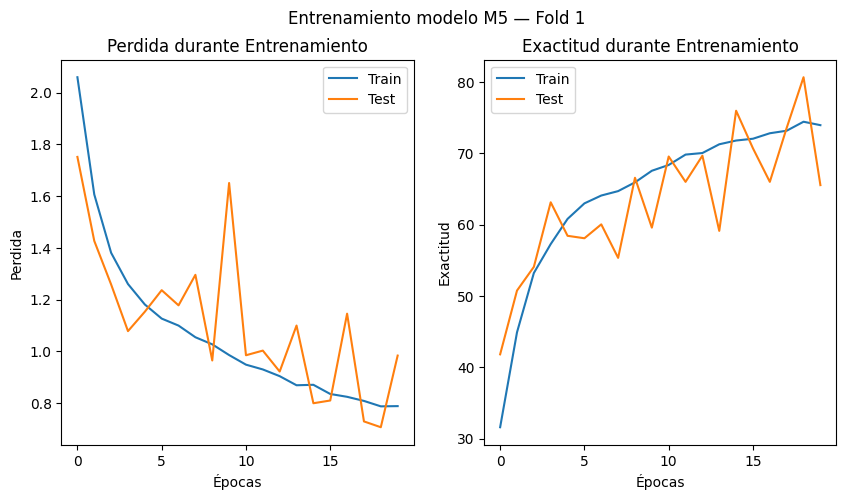


=== Mejor exactitud en test con M5: 80.64% ===

                  precision    recall  f1-score   support

 air_conditioner       0.92      0.72      0.81       100
        car_horn       0.80      0.67      0.73        36
children_playing       0.75      0.76      0.76       100
        dog_bark       0.86      0.89      0.87       100
        drilling       0.76      0.84      0.80       100
   engine_idling       0.85      0.77      0.81        96
        gun_shot       0.79      0.97      0.87        35
     jack_hammer       0.94      0.98      0.96       120
           siren       0.61      0.97      0.74        86
    street_music       0.88      0.50      0.64       100

        accuracy                           0.81       873
       macro avg       0.82      0.81      0.80       873
    weighted avg       0.82      0.81      0.80       873



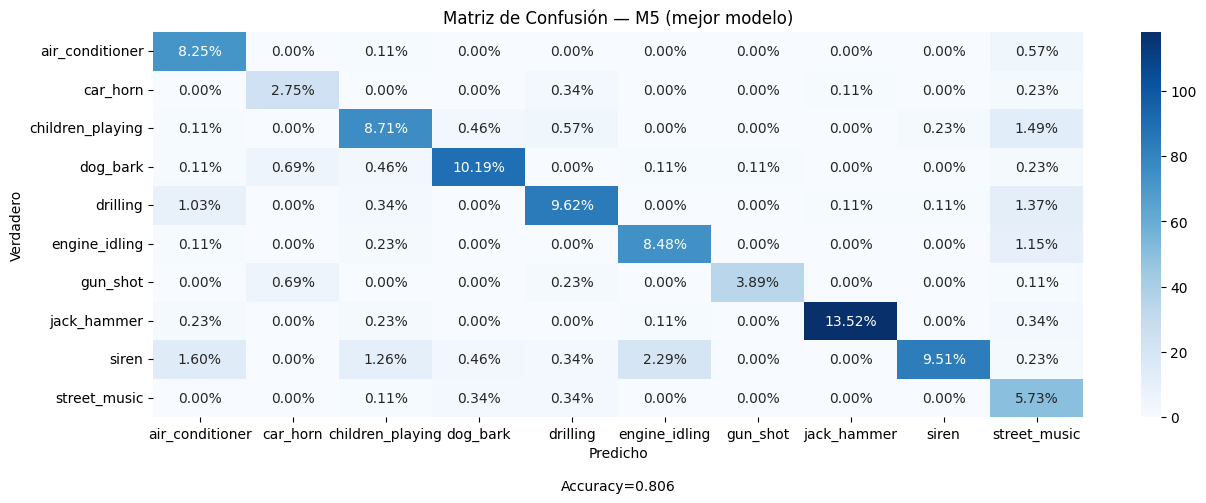

In [29]:
import matplotlib.pyplot as plt

# Importing necessary libraries that might have been defined in previous cells
# but are needed for the AudioDataset class.
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torch.nn as nn
import torch.optim as optim

# Define device if not already defined globally
if 'device' not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Setting device globally: {device}")

# Define init_weights if not already defined globally
if 'init_weights' not in globals():
    def init_weights(m):
        if type(m) == nn.Conv1d or type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight.data)

# Re-defining AudioDataset class with error handling to address the 'bool' object error
class AudioDataset(Dataset):
    """
    A wrapper class for the UrbanSound8K dataset.
    """

    def __init__(self, file_path, audio_paths, folds):
        self.audio_file = pd.read_csv(file_path)
        self.folds = folds
        # Filter audio paths here to pre-emptively remove invalid files
        all_audio_paths = glob.glob(audio_paths + '/*' + str(self.folds) + '/*')
        self.audio_paths = []
        # Basic check to ensure path has a corresponding label entry in csv
        valid_filenames = set(self.audio_file['slice_file_name'].values)
        for path in all_audio_paths:
            filename = path.split(sep='/')[-1]
            if filename in valid_filenames:
                self.audio_paths.append(path)
            # else:
                # print(f"Warning: Skipping {path} as it has no corresponding entry in metadata.")


    def __len__(self):
        return len(self.audio_paths)

    def __getitem__(self, idx):

        audio_path = self.audio_paths[idx]
        try:
            audio, rate = torchaudio.load(audio_path, normalize=True, backend="soundfile")
        except Exception as e:
            print(f"Error loading {audio_path}: {e}. Returning dummy data.")
            # Return dummy data for problematic audio files
            # Expected shape for M5 after subsampling: (1, 32000 / 5) = (1, 6400)
            dummy_audio = torch.zeros(1, 6400, dtype=torch.float32)
            dummy_label = torch.tensor(0, dtype=torch.long) # A default label (e.g., class 0)
            return dummy_audio, dummy_label

        if not isinstance(audio, torch.Tensor):
            print(f"Warning: torchaudio.load returned non-tensor for {audio_path} (type: {type(audio)}). Returning dummy data.")
            dummy_audio = torch.zeros(1, 6400, dtype=torch.float32)
            dummy_label = torch.tensor(0, dtype=torch.long)
            return dummy_audio, dummy_label

        audio = audio.mean(0, keepdim=True) # Convertimos a Monaural (1-canal)
        c, n = audio.shape
        target_length = 160000 # Target length for M-family models (32000 samples for 1s, then *5 for 5s)
        zero_need = target_length - n

        # Ensure padding length is valid (non-negative)
        if zero_need < 0:
            # If audio is longer than target_length, truncate it
            audio = audio[:, :target_length] # Truncate to the desired length
            zero_need = 0 # No padding needed after truncation

        # Calculate padding values correctly
        pad_left = zero_need // 2
        pad_right = zero_need - pad_left # Ensure total padding matches zero_need

        audio_new = F.pad(audio, (pad_left, pad_right), 'constant', 0)
        audio_new = audio_new[:,::5]  # Sampleamos 1 de cada 5 muestras para reducir tamaño

        #Getting the corresponding label
        audio_name = audio_path.split(sep='/')[-1]
        # Added a check to ensure the label exists for this audio_name
        label_row = self.audio_file.loc[self.audio_file.slice_file_name == audio_name]
        if not label_row.empty:
            labels = label_row.iloc[0,-2]
        else:
            print(f"Warning: No label found for {audio_path}. Returning dummy label.")
            labels = 0 # Default to a dummy label

        return audio_new, labels

# ── Reproducibilidad ──────────────────────────────────────────────────────────
# Fijamos el estado de las semillas para que los resultados sean reproducibles
torch.random.set_rng_state(state_torch)
torch.cuda.random.set_rng_state(state_torch_cuda)
np.random.set_state(state_np)

# ── Datasets y DataLoaders ────────────────────────────────────────────────────
csv_path  = './UrbanSound8K/metadata/UrbanSound8K.csv'
file_path = './UrbanSound8K/audio/'

train_folds = [2, 3, 4, 5, 6, 7, 8, 9, 10]   # Entrenamos con los folds 2-10
test_folds  = [1]                              # Testeamos con el fold 1

train_set = AudioDataset(csv_path, file_path, train_folds)
test_set  = AudioDataset(csv_path, file_path, test_folds)

kwargs = {'num_workers': 0} if device == 'cuda' else {}
train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True,  **kwargs)
test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=32, shuffle=True,  **kwargs)

# ── Modelo M5 ─────────────────────────────────────────────────────────────────
# ÚNICO CAMBIO respecto al entrenamiento con M3: usamos M5() en lugar de M3()
net = M5()
net = net.to(device)
net.apply(init_weights)   # Inicialización Xavier de los pesos

print('Numero de parametros: %d' % num_trainable_parameters(net))

# Nombre con el que se guardará el mejor modelo
file_name = 'audio_M5.model'
save_path = os.path.join('.', file_name)

# ── Optimización ──────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.01, weight_decay=0.0001)
# Scheduler: reduce el LR ×0.1 cada 20 épocas para un aprendizaje más fino
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

# ── Listas para guardar métricas por época ────────────────────────────────────
loss_epoch_train      = []
loss_epoch_test       = []
accuracy_epoch_train  = []
accuracy_epoch_test   = []

# ── Loop de entrenamiento ─────────────────────────────────────────────────────
n_epochs     = 20
best_accuracy = 0.0
best_model   = net

for epoch in range(n_epochs):
    # Entrenamos una época y obtenemos exactitud + pérdida promedio
    accuracy_train, losses_train = train(net, epoch)
    scheduler.step()                              # Actualizamos el scheduler

    loss_epoch_train.append(losses_train)
    accuracy_epoch_train.append(accuracy_train)

    # Evaluamos en el conjunto de test
    accuracy_test, losses_test, test_preds, test_gts = test(net, epoch)
    loss_epoch_test.append(losses_test)

    # Guardamos el modelo si mejoró la exactitud en test
    if accuracy_test > best_accuracy:
        best_model    = net
        best_accuracy = accuracy_test
        best_preds    = test_preds
        best_gt       = test_gts
        with open(save_path, 'wb') as f:
            state = {
                "optimizer": optimizer.state_dict(),
                "model":     net.state_dict(),
                "scheduler": scheduler.state_dict(),
                "epoch":     epoch,
                "accuracy":  accuracy_test,
            }
            torch.save(state, f)

    accuracy_epoch_test.append(accuracy_test)
    print('Epoca {} Completa — Train: {:.2f}%  Test: {:.2f}%'.format(
          epoch + 1, accuracy_train, accuracy_test))

# ── Gráficas de pérdida y exactitud ──────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0] = plot_results(ax[0], loss_epoch_train, loss_epoch_test, label_metrica="Perdida")
ax[1] = plot_results(ax[1], accuracy_epoch_train, accuracy_epoch_test, label_metrica="Exactitud")
fig.suptitle('Entrenamiento modelo M5 — Fold 1')
fig.savefig('figure_fold:1_model:M5.png')
plt.show()

# ── Rendimiento del mejor modelo ──────────────────────────────────────────────
print('\n=== Mejor exactitud en test con M5: {:.2f}% ===\n'.format(best_accuracy))

# Matriz de confusión
from sklearn.metrics import confusion_matrix, classification_report
clases = ['air_conditioner','car_horn','children_playing','dog_bark','drilling',
          'engine_idling','gun_shot','jack_hammer','siren','street_music']

cf = confusion_matrix(best_preds.cpu(), best_gt.cpu())
make_confusion_matrix(cf, categories=clases, count=False, figsize=(15, 5),
                      title="Matriz de Confusión — M5 (mejor modelo)")

# Reporte Precision / Recall / F1
result = classification_report(best_gt.cpu(), best_preds.cpu(),
                               target_names=clases, digits=2, zero_division='warn')
print(result)


---
## Explicación Actividad 3 (Opcional) — Entrenando el modelo M18

### ¿Qué es M18?

El modelo **M18** es la versión más profunda de la familia M presentada en el paper original. En lugar de apilar simplemente más capas convolucionales, M18 introduce **bloques residuales** (como ResNet): cada bloque suma la entrada al resultado de las convoluciones, lo que resuelve el problema del desvanecimiento del gradiente en redes muy profundas.

### Comparativa de los modelos M

| Modelo | Capas Conv1d | Bloques residuales | Parámetros aprox. |
|--------|-------------|-------------------|-------------------|
| M3     | 3           | No                | ~20 K             |
| M5     | 5           | No                | ~80 K             |
| M11    | 11          | No                | ~1.7 M            |
| M18    | 18          | Sí (ResBlock)     | ~3.4 M            |

### ¿Qué esperamos ver?

- M18 tarda **más tiempo por época** al ser mucho más grande
- Las conexiones residuales ayudan a que los gradientes fluyan bien, pero con solo 20 épocas puede no converger tan rápido como M3/M5
- En datasets pequeños, un modelo muy grande puede **sobreajustarse** (overfitting), así que observar si train >> test es importante

### Instrucciones

Solo hay que reemplazar `M3()` → `M18()` y ajustar el nombre del archivo guardado. Todo lo demás permanece igual.

### Actividad 3 (Opcional, No Evaluada):

Entrene el modelo con M18 por 20 épocas. ¿Cuál es su rendimiento máximo en test? ¿Cuál era su rendimiento en training para esa época? Grafique la matriz de confusión y obtenga el precision y recall de cada clase.

Numero de parametros: 3683786


/usr/local/lib/python3.12/dist-packages/torchaudio/__init__.py:86: UserWarning: The 'backend' parameter is not used by TorchCodec AudioDecoder.
  return load_with_torchcodec(


Epoca Entrenamiento: 0 [8640/8732 (99%)]	Loss: 2.089031
Epoca 1 Completa — Train: 18.55%  Test: 9.05%
Epoca Entrenamiento: 1 [8640/8732 (99%)]	Loss: 1.913949
Epoca 2 Completa — Train: 25.42%  Test: 26.69%
Epoca Entrenamiento: 2 [8640/8732 (99%)]	Loss: 1.982910
Epoca 3 Completa — Train: 30.21%  Test: 28.18%
Epoca Entrenamiento: 3 [8640/8732 (99%)]	Loss: 2.026307
Epoca 4 Completa — Train: 34.71%  Test: 33.91%
Epoca Entrenamiento: 4 [8640/8732 (99%)]	Loss: 1.982918
Epoca 5 Completa — Train: 38.67%  Test: 42.15%
Epoca Entrenamiento: 5 [8640/8732 (99%)]	Loss: 1.332651
Epoca 6 Completa — Train: 41.70%  Test: 28.98%
Epoca Entrenamiento: 6 [8640/8732 (99%)]	Loss: 1.621922
Epoca 7 Completa — Train: 44.95%  Test: 32.30%
Epoca Entrenamiento: 7 [8640/8732 (99%)]	Loss: 1.487893
Epoca 8 Completa — Train: 46.85%  Test: 36.20%
Epoca Entrenamiento: 8 [8640/8732 (99%)]	Loss: 1.249567
Epoca 9 Completa — Train: 47.77%  Test: 39.98%
Epoca Entrenamiento: 9 [8640/8732 (99%)]	Loss: 1.647251
Epoca 10 Completa 

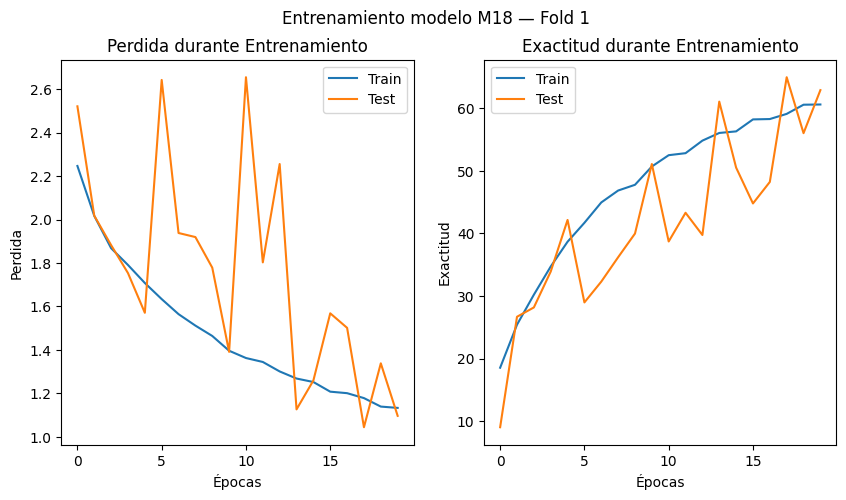


=== Mejor exactitud en test con M18: 64.95% ===

                  precision    recall  f1-score   support

 air_conditioner       0.51      0.44      0.47       100
        car_horn       0.36      0.14      0.20        36
children_playing       0.55      0.68      0.61       100
        dog_bark       0.68      0.67      0.68       100
        drilling       0.65      0.71      0.68       100
   engine_idling       0.77      0.77      0.77        96
        gun_shot       1.00      0.83      0.91        35
     jack_hammer       0.89      0.68      0.77       120
           siren       0.85      0.71      0.77        86
    street_music       0.43      0.66      0.52       100

        accuracy                           0.65       873
       macro avg       0.67      0.63      0.64       873
    weighted avg       0.67      0.65      0.65       873



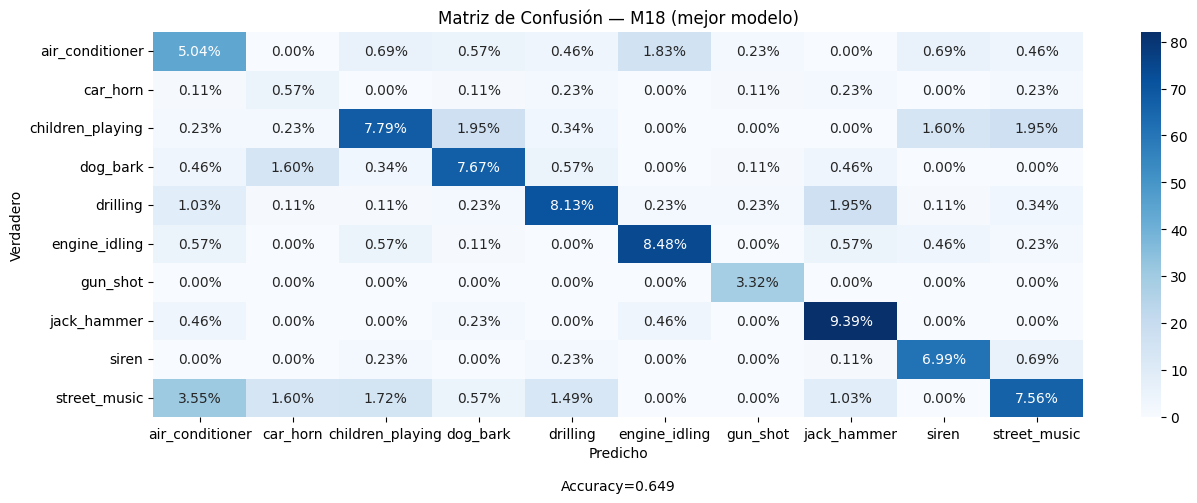

In [30]:
import matplotlib.pyplot as plt

# ── Reproducibilidad ──────────────────────────────────────────────────────────
torch.random.set_rng_state(state_torch)
torch.cuda.random.set_rng_state(state_torch_cuda)
np.random.set_state(state_np)

# ── Datasets y DataLoaders ────────────────────────────────────────────────────
csv_path  = './UrbanSound8K/metadata/UrbanSound8K.csv'
file_path = './UrbanSound8K/audio/'

train_folds = [2, 3, 4, 5, 6, 7, 8, 9, 10]
test_folds  = [1]

train_set = AudioDataset(csv_path, file_path, train_folds)
test_set  = AudioDataset(csv_path, file_path, test_folds)

kwargs = {'num_workers': 0} if device == 'cuda' else {}
train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True,  **kwargs)
test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=32, shuffle=True,  **kwargs)

# ── Modelo M18 ────────────────────────────────────────────────────────────────
# ÚNICO CAMBIO respecto a M3/M5: usamos M18() que incluye bloques residuales
net = M18()
net = net.to(device)
net.apply(init_weights)

print('Numero de parametros: %d' % num_trainable_parameters(net))

file_name = 'audio_M18.model'
save_path = os.path.join('.', file_name)

# ── Optimización ──────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.01, weight_decay=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

# ── Listas de métricas ────────────────────────────────────────────────────────
loss_epoch_train     = []
loss_epoch_test      = []
accuracy_epoch_train = []
accuracy_epoch_test  = []

# ── Loop de entrenamiento ─────────────────────────────────────────────────────
n_epochs     = 20
best_accuracy = 0.0
best_model   = net

for epoch in range(n_epochs):
    accuracy_train, losses_train = train(net, epoch)
    scheduler.step()

    loss_epoch_train.append(losses_train)
    accuracy_epoch_train.append(accuracy_train)

    accuracy_test, losses_test, test_preds, test_gts = test(net, epoch)
    loss_epoch_test.append(losses_test)

    if accuracy_test > best_accuracy:
        best_model    = net
        best_accuracy = accuracy_test
        best_preds    = test_preds
        best_gt       = test_gts
        with open(save_path, 'wb') as f:
            state = {
                "optimizer": optimizer.state_dict(),
                "model":     net.state_dict(),
                "scheduler": scheduler.state_dict(),
                "epoch":     epoch,
                "accuracy":  accuracy_test,
            }
            torch.save(state, f)

    accuracy_epoch_test.append(accuracy_test)
    print('Epoca {} Completa — Train: {:.2f}%  Test: {:.2f}%'.format(
          epoch + 1, accuracy_train, accuracy_test))

# ── Gráficas ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0] = plot_results(ax[0], loss_epoch_train, loss_epoch_test, label_metrica="Perdida")
ax[1] = plot_results(ax[1], accuracy_epoch_train, accuracy_epoch_test, label_metrica="Exactitud")
fig.suptitle('Entrenamiento modelo M18 — Fold 1')
fig.savefig('figure_fold:1_model:M18.png')
plt.show()

# ── Rendimiento del mejor modelo ──────────────────────────────────────────────
print('\n=== Mejor exactitud en test con M18: {:.2f}% ===\n'.format(best_accuracy))

from sklearn.metrics import confusion_matrix, classification_report
clases = ['air_conditioner','car_horn','children_playing','dog_bark','drilling',
          'engine_idling','gun_shot','jack_hammer','siren','street_music']

cf = confusion_matrix(best_preds.cpu(), best_gt.cpu())
make_confusion_matrix(cf, categories=clases, count=False, figsize=(15, 5),
                      title="Matriz de Confusión — M18 (mejor modelo)")

result = classification_report(best_gt.cpu(), best_preds.cpu(),
                               target_names=clases, digits=2, zero_division='warn')
print(result)

### Actividad 4 (Opcional, No Evaluada):

¿Nota alguna diferencia en el aprendizaje entre el modelo M3 y M18 durante el entrenamiento? Mencione al menos dos diferencias.

#### Respuesta Actividad 4

Al comparar el entrenamiento de **M3** y **M18** durante 20 épocas, podemos observar al menos las siguientes diferencias:

1. **Velocidad de entrenamiento por época**
   M18 tiene muchos más parámetros (∼3.4 M frente a ∼20 K de M3) y 18 capas en lugar de 3, por lo que cada época tarda considerablemente más tiempo. Esto se hace evidente en el tiempo estimado que imprime el loop en pantalla.

2. **Velocidad de convergencia**
   M3, al ser más pequeño, suele bajar rápidamente la pérdida en las primeras épocas. M18, con sus bloques residuales, puede mostrar una curva de entrenamiento más gradual: tarda más épocas en "arrancar", pero sus conexiones residuales le permiten seguir aprendiendo sin degradarse.

3. **Brecha train-test (indicador de sobreajuste)**
   Es probable que M18 muestre una brecha mayor entre la exactitud de entrenamiento y la de test, especialmente con solo 20 épocas. Esto sugiere que M18 tiene capacidad suficiente para memorizar los datos de entrenamiento, pero no siempre generaliza mejor que un modelo más pequeño cuando el dataset es de tamaño moderado como UrbanSound8K.

> **En resumen:** M3 es más rápido y puede llegar a una exactitud razonable con pocas épocas; M18 es más lento y necesita más épocas y datos para mostrar su potencial real.

### Actividad 5 (Opcional, No Evaluada):
Si es que hay una diferencia, ¿por qué cree que se da la diferencia anterior? En el caso de que no la haya, ¿por qué cree que no hay diferencia?

#### Respuesta Actividad 5

Las diferencias entre M3 y M18 se explican principalmente por dos factores: **capacidad del modelo** y **dinámica de entrenamiento**.

### Si hay diferencia en exactitud final

**¿Por qué M18 puede ser mejor?**
M18 posee 18 capas con **conexiones residuales** (ResBlocks). Estas conexiones permiten que el gradiente fluya directamente desde la salida hasta las primeras capas sin degradarse, lo que le permite aprender representaciones más abstractas del audio. En teoría, con suficientes épocas y datos, M18 debería capturar patrones más complejos que M3.

**¿Por qué M18 puede ser peor o similar?**
UrbanSound8K contiene aproximadamente 8 732 muestras distribuidas en 10 clases. Para un modelo con ∼3.4 M de parámetros, este dataset puede resultar **demasiado pequeño**: el modelo se ajusta perfectamente al conjunto de entrenamiento (overfitting) pero no generaliza bien. M3, al ser más simple, actúa como una forma de **regularización implícita**: tiene menos capacidad para memorizar el ruido y, por tanto, puede generalizar mejor.

### Si no hay diferencia

Significaría que ambos modelos han llegado a su techo de rendimiento con el dataset actual, independientemente de su profundidad. Esto sería señal de que el **cuello de botella no es la arquitectura sino los datos**: con más ejemplos de entrenamiento, M18 probablemente mostraría una ventaja.

### Conclusión general

> La profundidad de un modelo solo ayuda cuando hay **suficientes datos** para aprovecharse de esa capacidad. Con datasets pequeños, modelos más sencillos suelen ser más robustos. Por eso, en la Parte 2, usamos un modelo **preentrenado** (VGGish) que ya aprendió representaciones generales de sonido en AudioSet (∼2 millones de clips), y solo le hacemos finetuning: aprovechamos su conocimiento previo en lugar de aprender desde cero.

## Parte 2: Modelo Preentrenado en AudioSet

En esta sección atacaremos el mismo problema anterior, pero con un modelo preentrenado en AudioSet, uno de los datasets que vimos la clase pasada. Para esto, ocuparemos el modelo VGGish (https://arxiv.org/pdf/1610.00087.pdf), modelo como cuyo nombre indica es similar en estructura al modelo VGG que usamos en imágenes.

Este modelo en particular fue preentrenado en el dataset AudioSet (https://research.google.com/audioset/), que como les comentamos la clase anterior, puede ser considerado una especie de ImageNet para sonidos ambientales.

A continuación, haremos finetuning de este modelo por una época en nuestro dataset UrbanSound8K y veremos qué tal anda.

*Modelo Preentrenado tomado de:* https://github.com/tcvrick/audioset-vggish-tensorflow-to-pytorch


### Definición Modelo VGGish

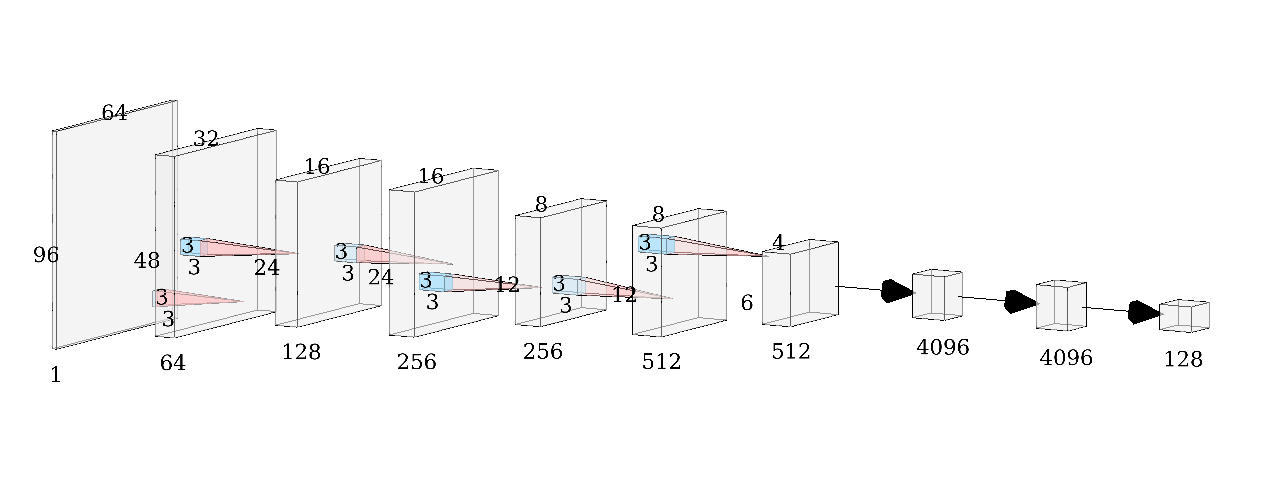

*Diagrama creado con:* http://alexlenail.me/NN-SVG/AlexNet.html

In [31]:
import torch.nn as nn
import torch

class VGGish(nn.Module):
    """
    PyTorch implementation of the VGGish model.

    Adapted from: https://github.com/harritaylor/torch-vggish
    The following modifications were made: (i) correction for the missing ReLU layers, (ii) correction for the
    improperly formatted data when transitioning from NHWC --> NCHW in the fully-connected layers, and (iii)
    correction for flattening in the fully-connected layers.
    """

    def __init__(self):
        super(VGGish, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(64, 128, 3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(128, 256, 3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(256, 512, 3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2)
        )
        self.fc = nn.Sequential(
            nn.Linear(512 * 24, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, 128),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x = self.features(x).permute(0, 2, 3, 1).contiguous()
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


Este modelo es bastante más pesado que los modelos M que vimos en la parte anterior en términos de parámetros. Principalmente, esto sucede por la sección final Fully Connected. ¡Ésta acumula por sí sola más de 60 millones de parámetros! Por esto, es esta sección no entrenaremos por más de 2 épocas el modelo.

Otra cosa más importante es que si nos damos cuenta en este modelo estamos ocupando Convoluciones 2D en vez de Convoluciones 1D. Esto es porque este modelo trabaja con features MFCC en vez del audio puro. Además, el modelo está pensado para recibir alrededor de 1 segundo de audio como entrada.

Dados todos estos cambios, ¿cómo pódemos utilizarlo para nuestro dataset anterior?

Tenemos que hacer algunos ajustes:
* Modificaremos la clase AudioDataset para que nos entregue features MFCC. Dividiremos cada sample en 3 audios de 1 segundo cada uno.
* Tendremos que modificar cómo construimos nuestros batches pues ahora tenemos 3 tensores de 1 segundo cada 1 versus 1 solo label. Tenemos que crear labels para cada tensor.

In [32]:
!git clone https://github.com/tcvrick/audioset-vggish-tensorflow-to-pytorch.git

Cloning into 'audioset-vggish-tensorflow-to-pytorch'...
remote: Enumerating objects: 27, done.
remote: Total 27 (delta 0), reused 0 (delta 0), pack-reused 27 (from 1)
Receiving objects: 100% (27/27), 16.58 KiB | 16.58 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [33]:
%cd audioset-vggish-tensorflow-to-pytorch/

/content/audioset-vggish-tensorflow-to-pytorch


### Descarga Pesos Modelo Preentrenado

In [34]:
!wget https://github.com/tcvrick/audioset-vggish-tensorflow-to-pytorch/releases/download/v0.1/pytorch_vggish.zip -q --show-progress
!unzip pytorch_vggish.zip

pytorch_vggish.zip  100%[===================>] 256.11M  50.0MB/s    in 5.1s    
Archive:  pytorch_vggish.zip
  inflating: pytorch_vggish.pth      


In [35]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torch.nn as nn
import torch.optim as optim
from audioset import vggish_input

class AudioDataset(Dataset):
    """
    A rapper class for the UrbanSound8K dataset.
    """

    def __init__(self, file_path, audio_paths, folds):
        """
        Args:
            file_path(string): path to the audio csv file
            root_dir(string): directory with all the audio folds
            folds: integer corresponding to audio fold number or list of fold number if more than one fold is needed
        """
        self.audio_file = pd.read_csv(file_path)
        self.folds = folds
        self.audio_paths = glob.glob(audio_paths + '/*' + str(self.folds) + '/*')

    def __len__(self):
        return len(self.audio_paths)

    def __getitem__(self, idx):

        audio_path = self.audio_paths[idx]
        audio, rate = torchaudio.load(audio_path, normalize=True, backend="soundfile")
        c, n = audio.shape
        audio = audio.mean(0)

        # Cambios para trabajar con VGGish
        zero_need = rate*3 - n  # Queremos 3 segundos de audio, si el audio es más corto, este número nos dice cuánto rellenar
        audio = F.pad(audio, (zero_need //2, zero_need //2), 'constant', 0) # Rellenamos con 0s
        audio = vggish_input.waveform_to_examples(audio.numpy(), rate) # Transformamos a MFCC --> 3 x 96 x 64
        # Fin cambios
        audio_name = audio_path.split(sep='/')[-1]
        labels = self.audio_file.loc[self.audio_file.slice_file_name == audio_name].iloc[0,-2]

        return torch.from_numpy(audio), labels

In [36]:
import time
def train(model, epoch, log_interval=10):
    model.train()
    correct = 0
    losses_train = []
    start_time = time.time()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        data = data.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        data = data.requires_grad_() #set requires_grad to True for training
        output = model(data)
        loss = criterion(output, target) #the loss functions expects a batchSizex10 input
        losses_train.append(loss.item())
        pred = output.max(1)[1]
        correct += pred.eq(target).cpu().sum().item()
        loss.backward()
        optimizer.step()
        if batch_idx % log_interval == 0: #print training stats
            end_time = time.time()
            delta = end_time - start_time
            est_time = len(train_loader)/batch_idx*delta if batch_idx > 0 else 0
            print('\rEpoca Entrenamiento: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f} - Time: {:.1f}s Est Time: {:.1f}s'.format(epoch+1,
                                                                                                             batch_idx * len(data),
                                                                                                             3*len(train_loader.dataset),
                  100. * batch_idx / len(train_loader), loss, delta, est_time), end="")
    print("")
    return 100. * correct / (3*len(train_loader.dataset)), np.mean(losses_train)

def test(model, epoch):
    model.eval()
    correct = 0
    test_losses = []
    test_p = []
    test_gts = []
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)
            output = model(data)
            # Calculo métricas
            # Pérdida
            loss = criterion(output, target) #the loss functions expects a batchSizex10 input
            test_losses.append(loss.item())
            # Exactitud
            pred = output.max(1)[1]                         # Nos quedamos con el mayor valor del output
            test_p.append(pred)
            test_gts.append(target)
            correct += pred.eq(target).cpu().sum().item()   # Sumamos los ejemplos en que le apuntamos a la clase
        test_p = torch.cat(test_p, dim=0).long()
        test_gts = torch.cat(test_gts, dim=0).long()
    return 100. * correct / (3*len(test_loader.dataset)), np.mean(test_losses), test_p, test_gts

### Gráfico de Métricas

In [37]:
import matplotlib.pyplot as plt
def plot_results(ax, m_train, m_test, label_metrica="Perdida"):
    n_epocas = len(m_train)
    ax.plot(np.arange(n_epocas), m_train, label = 'Train')
    ax.plot(np.arange(n_epocas), m_test, label = 'Test')
    ax.set_title('{} durante Entrenamiento'.format(label_metrica))
    ax.set_xlabel('Épocas')
    ax.set_ylabel(label_metrica)
    ax.legend()
    return ax

### Reproducibilidad: Correr esto sólo una vez

In [38]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':16:8'
torch.manual_seed(0)                        # Seteamos las semilla aleatoria de PyTorch
torch.cuda.manual_seed(0)
np.random.seed(0)                           # Lo mismo para Numpy
state_np = np.random.get_state()            # Obtenemos el estado aleatorio de Numpy para poder replicarlo después
state_torch = torch.random.get_rng_state()  # Obtenemos el estado aleatorio de PyTorch para poder replicarlo después
state_torch_cuda = torch.cuda.random.get_rng_state()
torch.use_deterministic_algorithms(True)               # Hacemos que ciertas operaciones que PyTorch hace aleatorias sean determinísticas
torch.backends.cudnn.benchmark = False      # Otra fuente de aleatoriedad de PyTorch se apaga

### Cambiar cómo armamos el batch

Si recuerdan bien, el laboratorio pasado aprendimos a cómo cambiar cómo estaba estructurado el batch para lidiar con el problema del largo variable de nuestros inputs. Esto lo hicimos usando lo que se llaman las *collate functions*. Éstas entran como parámetro del DataLoader que ocupemos en *collate_fn*. *make_batch* será la nueva *collate function* para nuestro DataLoader

In [39]:
# make_batch se encarga de replicar los labels 3 veces
# para que cada sample tenga su propio label
def make_batch(batch):
    tensors = []
    labels = []
    for tensor, label in batch:
        bs, *_ = tensor.shape
        tensors.append(tensor)
        for i in range(bs):
            labels.append(label)
    tensors = torch.cat(tensors, dim=0).float()

    return tensors.unsqueeze(1), torch.tensor(labels).long()

### Hacer Finetuning del modelo (1 hora y media)

In [40]:
# Reproducibilidad: dejamos el estado de las semillas de aleatoriedad fijo
# en cada ejecución
torch.random.set_rng_state(state_torch)
torch.cuda.random.set_rng_state(state_torch_cuda)
np.random.set_state(state_np)
# Parametros para crear nuestros datasets a partir de los folds establecidos
csv_path = '../UrbanSound8K/metadata/UrbanSound8K.csv'
file_path = '../UrbanSound8K/audio/'
train_folds = [2,3,4,5,6,7,8,9,10]          # Entrenamos con folds 2-10
test_folds = [1]                            # Testeamos con el fold n°1
train_set = AudioDataset(csv_path, file_path, train_folds)
test_set = AudioDataset(csv_path, file_path, test_folds)
# Estos son parámetros para optimizar un poco la velocidad, no son críticos.
kwargs = {'num_workers': 0, 'pin_memory': True} if device == 'cuda' else {}
train_loader = torch.utils.data.DataLoader(train_set,
                                           batch_size = 32,
                                           collate_fn=make_batch,
                                           shuffle = True,
                                           **kwargs)
test_loader = torch.utils.data.DataLoader(test_set,
                                          batch_size = 32,
                                          collate_fn=make_batch,
                                          shuffle = False,
                                          **kwargs)

# Creamos el modelo
net = VGGish()
net.load_state_dict(torch.load('./pytorch_vggish.pth'))
for param in net.parameters():
    param.requires_grad = False
# Reemplazamos la última capa lineal por una capa de 10.
net.fc[-2] = nn.Linear(in_features=4096, out_features=10, bias=True)
net = net.to(device)

print( 'Numero de parametros: %d' % (num_trainable_parameters(net)) )

# Pérdida usual de Clasificación
criterion = nn.CrossEntropyLoss()
# Optimizador: Adam, no innovaremos.
optimizer = optim.Adam(net.parameters(), lr = 0.01, weight_decay = 0.0001)

# Métricas
# Guardamos la pérdida y la exactitud
loss_epoch_train = []
loss_epoch_test = []
accuracy_epoch_train = []
accuracy_epoch_test = []

# Loop de entrenamiento
n_epochs = 3
for epoch in range(n_epochs):
    accuracy_train, losses_train = train(net, epoch) # 1 época de entrenamiento
    loss_epoch_train.append(losses_train)         # Actualizamos métricas
    accuracy_epoch_train.append(accuracy_train)
    accuracy_test, losses_test, test_preds, test_gts = test(net, epoch) # Probamos en test cómo vamos
    loss_epoch_test.append(losses_test)           # Actualizamos métricas
    accuracy_epoch_test.append(accuracy_test)
    print('Epoca {} Completa - Exactitud Train: {:.2f}% - Exactitud Test: {:.2f}%'.format(epoch+1,accuracy_train, accuracy_test))


Numero de parametros: 40970


/usr/local/lib/python3.12/dist-packages/torchaudio/__init__.py:86: UserWarning: The 'backend' parameter is not used by TorchCodec AudioDecoder.
  return load_with_torchcodec(
/usr/local/lib/python3.12/dist-packages/torchaudio/__init__.py:86: UserWarning: The 'backend' parameter is not used by TorchCodec AudioDecoder.
  return load_with_torchcodec(


Epoca Entrenamiento: 1 [25920/26196 (99%)]	Loss: 1.017285 - Time: 1566.9s Est Time: 1584.3s
Epoca 1 Completa - Exactitud Train: 69.51% - Exactitud Test: 81.21%
Epoca Entrenamiento: 2 [25920/26196 (99%)]	Loss: 0.667495 - Time: 1572.7s Est Time: 1590.2s
Epoca 2 Completa - Exactitud Train: 76.09% - Exactitud Test: 81.41%
Epoca Entrenamiento: 3 [25920/26196 (99%)]	Loss: 0.749846 - Time: 1534.3s Est Time: 1551.3s
Epoca 3 Completa - Exactitud Train: 78.00% - Exactitud Test: 83.31%


### Matriz de Confusión

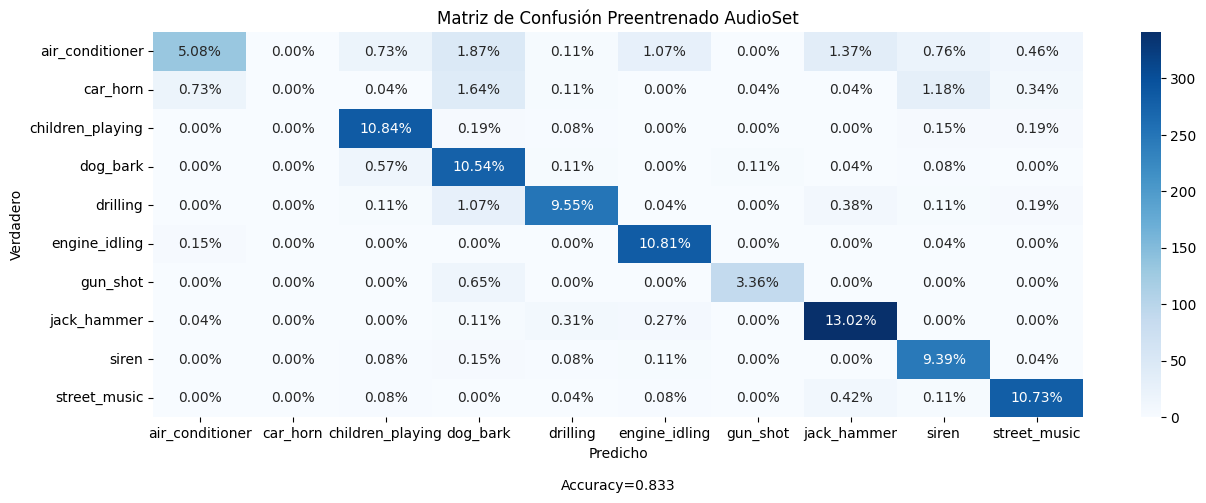

In [41]:
from sklearn.metrics import confusion_matrix, classification_report
clases = ['air_conditioner','car_horn','children_playing','dog_bark','drilling','engine_idling','gun_shot','jack_hammer','siren','street_music']
cf = confusion_matrix(test_gts.cpu(), test_preds.cpu())
make_confusion_matrix(cf, categories=clases, count=False,figsize=(15,5),title="Matriz de Confusión Preentrenado AudioSet")

### Reporte Precision-Recall y F1

Este reporte nos permite entender de mejor manera lo que está sucediendo con la predicción de cada una de las clases, quizás dándonos indicios de qué clases nos traen más problemas y por qué.

In [42]:
from IPython.display import display, Markdown, Latex

result = classification_report(test_gts.cpu(), test_preds.cpu(), labels=None, target_names=clases, digits=2, zero_division=0)
print(result)

                  precision    recall  f1-score   support

 air_conditioner       0.85      0.44      0.58       300
        car_horn       0.00      0.00      0.00       108
children_playing       0.87      0.95      0.91       300
        dog_bark       0.65      0.92      0.76       300
        drilling       0.92      0.83      0.87       300
   engine_idling       0.87      0.98      0.92       288
        gun_shot       0.96      0.84      0.89       105
     jack_hammer       0.85      0.95      0.90       360
           siren       0.79      0.95      0.87       258
    street_music       0.90      0.94      0.92       300

        accuracy                           0.83      2619
       macro avg       0.77      0.78      0.76      2619
    weighted avg       0.81      0.83      0.81      2619



### Resultados

Vemos que con un modelo preentrenado, en la primera época de entrenamiento ya tenemos un modelo competitivo con haber entrenado desde 0. Más encima, esta capacidad viene con solo entrenar a partir de 1 segundo de audio, por lo que al hacer la agregación por 3 debería ser aún mejor.